## Video Game Sales Analysis
An exploratory analysis of historical video game sales data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## Dataset Exploration

In [ ]:

df = pd.read_csv('../data/vgsales.csv')

df.head()

## Top 5 selling games

In [ ]:
top_games = df[['Name', 'Global_Sales']].sort_values(
    by='Global_Sales',
    ascending=False
).head(5)

top_games

## Top 5 Plataforms by sales

In [ ]:
top_platforms_sales = df.groupby(
    'Platform'
)['Global_Sales'].sum().sort_values(
    ascending=False
).head(5)

top_platforms_sales.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Top 5 Platforms by Global Sales')
plt.xlabel('Platform')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig('../images/top_platforms_sales.png')

plt.show()

## Best selling plataform by year

In [ ]:
platform_year = df.groupby(
    ['Year', 'Platform']
)['Global_Sales'].sum().reset_index()

best_platform_by_year = platform_year.loc[
    platform_year.groupby('Year')['Global_Sales'].idxmax()
]

best_platform_by_year

## Best selling game by year

In [ ]:
games_year = df.groupby(
    ['Year', 'Name']
)['Global_Sales'].sum().reset_index()

best_game_by_year = games_year.loc[
    games_year.groupby('Year')['Global_Sales'].idxmax()
]

best_game_by_year

## Year with most sales

In [ ]:
sales_year = df.groupby(
    'Year'
)['Global_Sales'].sum().sort_values(
    ascending=False
)

sales_year.head(1)

## Global sales over the years

In [ ]:
sales_by_year = df.groupby(
    'Year'
)['Global_Sales'].sum()

sales_by_year.plot(
    kind='line',
    figsize=(12, 6)
)

plt.title('Global Video Game Sales Over the Years')
plt.xlabel('Year')
plt.ylabel('Global Sales (Millions)')

plt.tight_layout()

plt.savefig('../images/global_sales_over_years.png')

plt.show()

## Plataform with most games released

In [ ]:
platform_games_count = df['Platform'].value_counts()

platform_games_count

## Top 10 plataforms with most games released

In [ ]:
platform_games_count.head(10).plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Top 10 Platforms by Number of Games Released')
plt.xlabel('Platform')
plt.ylabel('Number of Games')

plt.tight_layout()

plt.savefig('../images/platforms_most_games.png')

plt.show()

## Plataform with most global sales

In [ ]:
platform_global_sales = df.groupby(
    'Platform'
)['Global_Sales'].sum().sort_values(
    ascending=False
)

platform_global_sales

## Sales evolution of main platforms

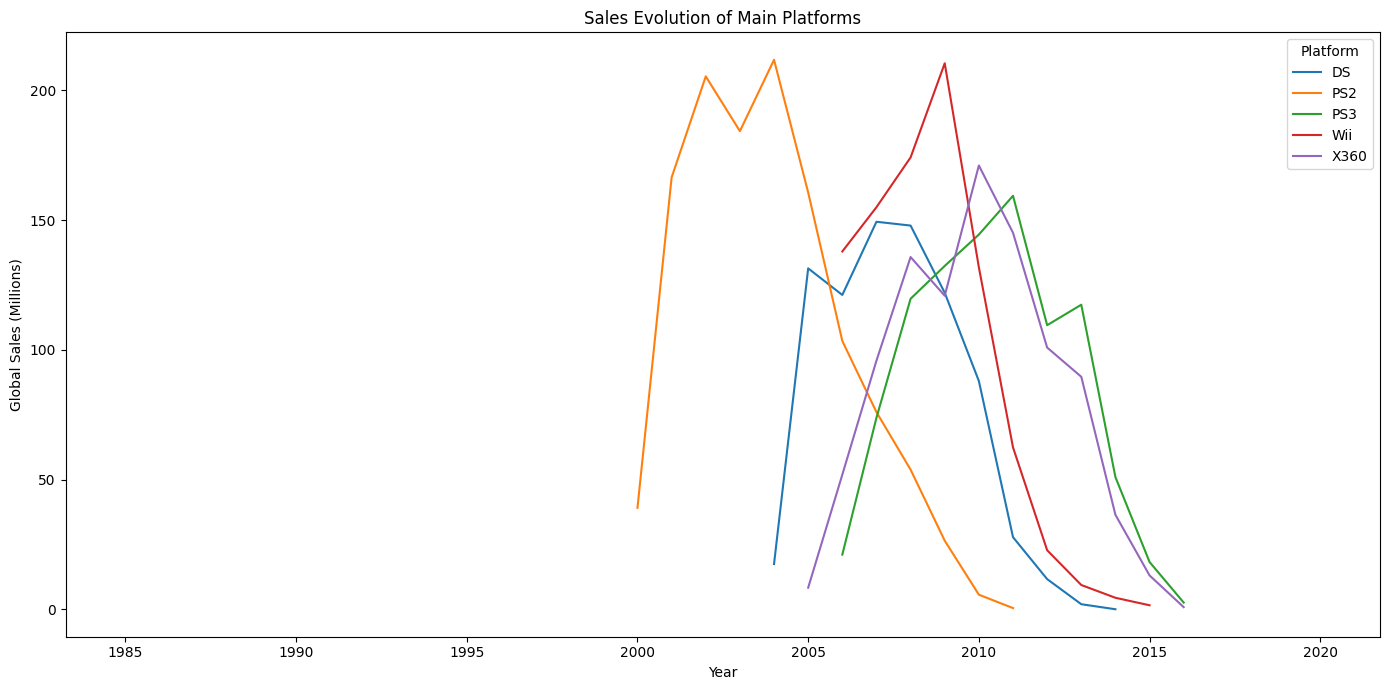

In [26]:
platform_trend = df.groupby(
    ['Year', 'Platform']
)['Global_Sales'].sum().reset_index()

top_platforms = ['PS2', 'X360', 'Wii', 'PS3', 'DS']

filtered = platform_trend[
    platform_trend['Platform'].isin(top_platforms)
]

pivot = filtered.pivot(
    index='Year',
    columns='Platform',
    values='Global_Sales'
)

pivot.plot(
    figsize=(14, 7)
)

plt.title('Sales Evolution of Main Platforms')
plt.xlabel('Year')
plt.ylabel('Global Sales (Millions)')

plt.tight_layout()

plt.savefig('../images/platform_sales_evolution.png')

plt.show()